## Load Data Files

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options for better viewing of DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

### 1. Power Logs: `power_log_g2l.csv`

In [ ]:
try:
    power_df = pd.read_csv('/content/power_logs/power_log_g2l.csv')
    print('Successfully loaded power_log_g2l.csv')
    display(power_df.head())
except FileNotFoundError:
    print('Error: power_log_g2l.csv not found. Please ensure the file is in the correct path.')
except Exception as e:
    print(f'An error occurred while loading power_log_g2l.csv: {e}')

Successfully loaded power_log_g2l.csv


,timestamp,power.draw [W]
0,Fri Apr 3 15:34:54 IDT 2026,132 W
1,Fri Apr 3 15:34:54 IDT 2026,100 W
2,Fri Apr 3 15:34:54 IDT 2026,115 W
3,Fri Apr 3 15:34:54 IDT 2026,131 W
4,Fri Apr 3 15:34:54 IDT 2026,119 W


### 2. Benchmark Results: `alpaca_benchmark_results_g2l.csv`

In [ ]:
try:
    benchmark_df = pd.read_csv('/content/benchmark_logs/alpaca_benchmark_results_g2l.csv')
    print('Successfully loaded alpaca_benchmark_results_g2l.csv')
    display(benchmark_df.head())
except FileNotFoundError:
    print('Error: alpaca_benchmark_results_g2l.csv not found. Please ensure the file is in the correct path.')
except Exception as e:
    print(f'An error occurred while loading alpaca_benchmark_results_g2l.csv: {e}')

Successfully loaded alpaca_benchmark_results_g2l.csv


,prompt,tokens_generated,ttft,mean_itl,median_itl,throughput
0,Instruction: Give three tips for staying healt...,1024,3.6524,0.0292,0.0227,30.53
1,Instruction: What are the three primary colors...,573,5.9135,0.0275,0.0233,26.47
2,Instruction: Describe the structure of an atom...,659,5.9114,0.0268,0.0231,28.02
3,Instruction: How can we reduce air pollution? ...,459,5.9052,0.0239,0.0235,27.27
4,Instruction: Describe a time when you had to m...,748,5.8982,0.0261,0.0230,29.42


In [ ]:
import glob
import os

# ===== LOAD BENCHMARK DATA =====
BENCHMARK_DIR = '/content/benchmark_logs'  # Directory containing benchmark CSVs
benchmark_csv_files = glob.glob(os.path.join(BENCHMARK_DIR, "*.csv"))

bench_data = {}
bench_throughput = {}
bench_ttft_data = {}
bench_ttft = {}
bench_mean_itl_data = {}
bench_mean_itl = {}
bench_median_itl_data = {}
bench_median_itl = {}


for file in benchmark_csv_files:
    df = pd.read_csv(file)

    # Ensure required columns exist
    required_cols = ['throughput', 'ttft', 'mean_itl', 'median_itl']
    if not all(col in df.columns for col in required_cols):
        print(f"⚠️ One or more required columns ({', '.join(required_cols)}) not found in {file}, skipping...")
        continue

    run_name = os.path.splitext(os.path.basename(file))[0] # e.g., alpaca_benchmark_results_g2l
    # Normalize run_name for plotting (e.g., 'g2l' from 'alpaca_benchmark_results_g2l')
    # Assuming the format is 'prefix_gXX.csv'
    parts = run_name.split('_')
    if len(parts) >= 2 and parts[-1].startswith('g'):
        clean_run_name = parts[-1] # e.g., g2l
    else:
        clean_run_name = run_name # Fallback if naming convention changes

    # Store values and calculate average for each metric
    bench_data[clean_run_name] = df['throughput'].tolist()
    bench_throughput[clean_run_name] = df['throughput'].mean()

    bench_ttft_data[clean_run_name] = df['ttft'].tolist()
    bench_ttft[clean_run_name] = df['ttft'].mean()

    bench_mean_itl_data[clean_run_name] = df['mean_itl'].tolist()
    bench_mean_itl[clean_run_name] = df['mean_itl'].mean()

    bench_median_itl_data[clean_run_name] = df['median_itl'].tolist()
    bench_median_itl[clean_run_name] = df['median_itl'].mean()


print("Loaded benchmark data:")
for run, avg_tput in bench_throughput.items():
    print(f"  {run}: Average Throughput = {avg_tput:.2f}")
    print(f"  {run}: Average TTFT = {bench_ttft[run]:.2f}")
    print(f"  {run}: Average Mean ITL = {bench_mean_itl[run]:.2f}")
    print(f"  {run}: Average Median ITL = {bench_median_itl[run]:.2f}")

Loaded benchmark data:
  g2m: Average Throughput = 25.30
  g2m: Average TTFT = 0.68
  g2m: Average Mean ITL = 0.04
  g2m: Average Median ITL = 0.04
  g2l: Average Throughput = 40.84
  g2l: Average TTFT = 0.47
  g2l: Average Mean ITL = 0.02
  g2l: Average Median ITL = 0.02
  g3l: Average Throughput = 42.48
  g3l: Average TTFT = 0.46
  g3l: Average Mean ITL = 0.02
  g3l: Average Median ITL = 0.02
  g3m: Average Throughput = 30.29
  g3m: Average TTFT = 0.38
  g3m: Average Mean ITL = 0.03
  g3m: Average Median ITL = 0.03


### 3. Server Logs: `server_benchmark_g2l_16.log`

In [ ]:
try:
    with open('/content/server_logs/server_benchmark_g2l_16.log', 'r') as f:
        server_log_content = f.readlines()
    print('Successfully loaded server_benchmark_g2l_16.log')
    print('First 10 lines of the log file:')
    for i, line in enumerate(server_log_content[:10]):
        print(line.strip())
except FileNotFoundError:
    print('Error: server_benchmark_g2l_16.log not found. Please ensure the file is in the correct path.')
except Exception as e:
    print(f'An error occurred while loading server_benchmark_g2l_16.log: {e}')

Successfully loaded server_benchmark_g2l_16.log
First 10 lines of the log file:
INFO 04-03 15:33:01 [__init__.py:254] Automatically detected platform hpu.
WARNING 04-03 15:33:04 [api_server.py:114] Starting from v1.23.0, the vLLM fork will reach end-of-life (EOL) and be deprecated in v1.24.0, remaining functional only for legacy use cases until then.
WARNING 04-03 15:33:04 [api_server.py:114] At the same time, the vllm-gaudi plugin will be production-ready in v1.23.0 and will become the default by v1.24.0.
WARNING 04-03 15:33:04 [api_server.py:114] This plugin integrates Intel Gaudi with vLLM for optimized LLM inference and is intended for future deployments.
WARNING 04-03 15:33:04 [api_server.py:114] We strongly suggest preparing a migration path toward the plugin version: https://github.com/vllm-project/vllm-gaudi
INFO 04-03 15:33:04 [config.py:1975] Disabled the custom all-reduce kernel because it is not supported on current platform.
INFO 04-03 15:33:05 [config.py:1975] Disabled th

In [ ]:
log_files = {
    'g2l': '/content/server_logs/server_benchmark_g2l_16.log',
    'g2m': '/content/server_logs/server_benchmark_g2m_16.log',
    'g3l': '/content/server_logs/server_benchmark_g3l_16.log',
    'g3m': '/content/server_logs/server_benchmark_g3m_16.log',
}

for var_name, file_path in log_files.items():
    try:
        with open(file_path, 'r') as f:
            globals()[var_name] = f.read()
        print(f'Successfully loaded {file_path} into variable {var_name}')
    except FileNotFoundError:
        print(f'Error: {file_path} not found. Please ensure the file is in the correct path.')
    except Exception as e:
        print(f'An error occurred while loading {file_path}: {e}')


Successfully loaded /content/server_logs/server_benchmark_g2l_16.log into variable g2l
Successfully loaded /content/server_logs/server_benchmark_g2m_16.log into variable g2m
Successfully loaded /content/server_logs/server_benchmark_g3l_16.log into variable g3l
Successfully loaded /content/server_logs/server_benchmark_g3m_16.log into variable g3m


In [ ]:
import pandas as pd
import glob
import os
import numpy as np

# ===== SETTINGS =====
DATA_DIR = "./power_logs"  # Change to your folder path

# Distinct colors for each config
color_map = {
    "2": "#1f77b4",    # blue
    "2s": "#ff7f0e",   # orange
    "2m": "#2ca02c",   # green
    "2l": "#d62728",   # red
    "3": "#9467bd",    # purple
    "3s": "#8c564b",   # brown
    "3m": "#e377c2",   # pink
    "3l": "#7f7f7f",   # gray
}

# Line styles
style_map = {"": "-.", "s": "-", "m": "--", "l": ":"}

# Order for plotting
plot_order = ["2", "2s", "2m", "2l", "3", "3s", "3m", "3l"]

# ===== LOAD DATA =====
csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
data_dict = {}
max_values = {}
meta_info = {}

for file in csv_files:
    df = pd.read_csv(file)

    # Find power column
    power_col = None
    for col in df.columns:
        if "power" in col.lower():
            power_col = col
            break
    if power_col is None:
        print(f"⚠️ No power column found in {file}, skipping...")
        continue

    run_name = os.path.splitext(os.path.basename(file))[0]  # e.g., power_logs_g2s

    # Parse version & config
    parts = run_name.split("_")
    if len(parts) >= 2:
        version_config = parts[-1]  # e.g., 'g2', 'g2s', 'g3m'
        if version_config.startswith("g"):
            norm_cfg = version_config[1:]  # strip 'g' → '2', '2s', '3m', etc.
        else:
            norm_cfg = version_config
        gaudi_version = norm_cfg[0]  # '2' or '3'
        cfg_suffix = norm_cfg[1:]    # '', 's', 'm', 'l'
        meta_info[run_name] = (gaudi_version, cfg_suffix, norm_cfg)
    else:
        meta_info[run_name] = ("?", "?", "?")
        norm_cfg = "?"

    # Clean values
    power_values = (
        df[power_col]
        .astype(str)
        .str.strip()
        .str.replace("W", "", regex=False)
        .str.replace("w", "", regex=False)
        .astype(float)
        .dropna()
        .to_numpy()
    )

    data_dict[run_name] = power_values
    max_values[run_name] = np.max(power_values)

# ===== ALIGN FOR MAX =====
max_aligned_data = {}
max_length = max(len(v) for v in data_dict.values())

for run, values in data_dict.items():
    max_idx = np.argmax(values)
    shift = (max_length // 2) - max_idx
    aligned = np.full(max_length, np.nan)
    start = max(0, shift)
    end = min(max_length, shift + len(values))
    aligned[start:end] = values[:end - start]
    max_aligned_data[run] = aligned

# ===== SORT =====
sorted_runs = sorted(
    data_dict.keys(),
    key=lambda x: plot_order.index(meta_info[x][2]) if meta_info[x][2] in plot_order else 999
)

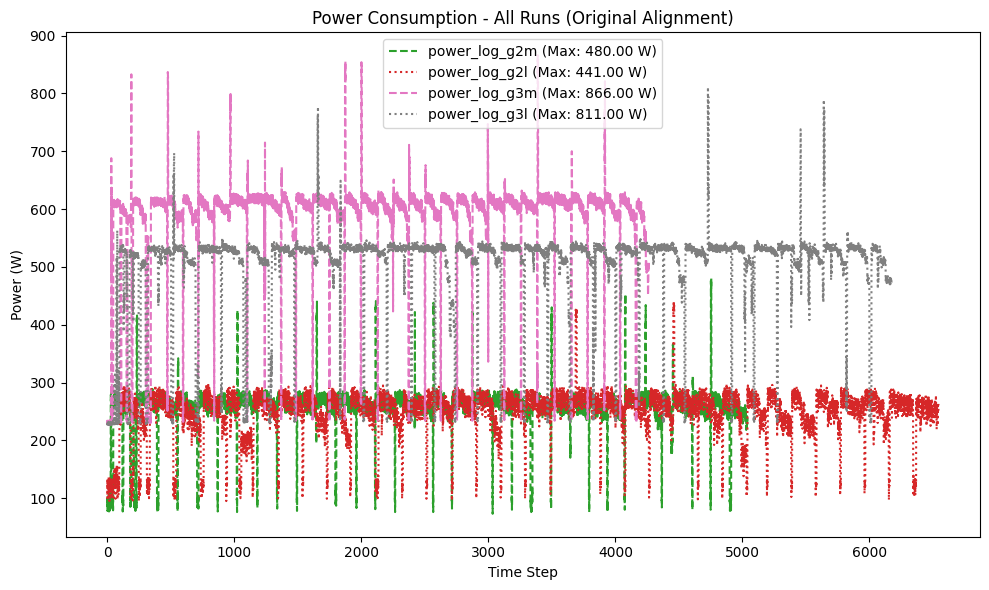

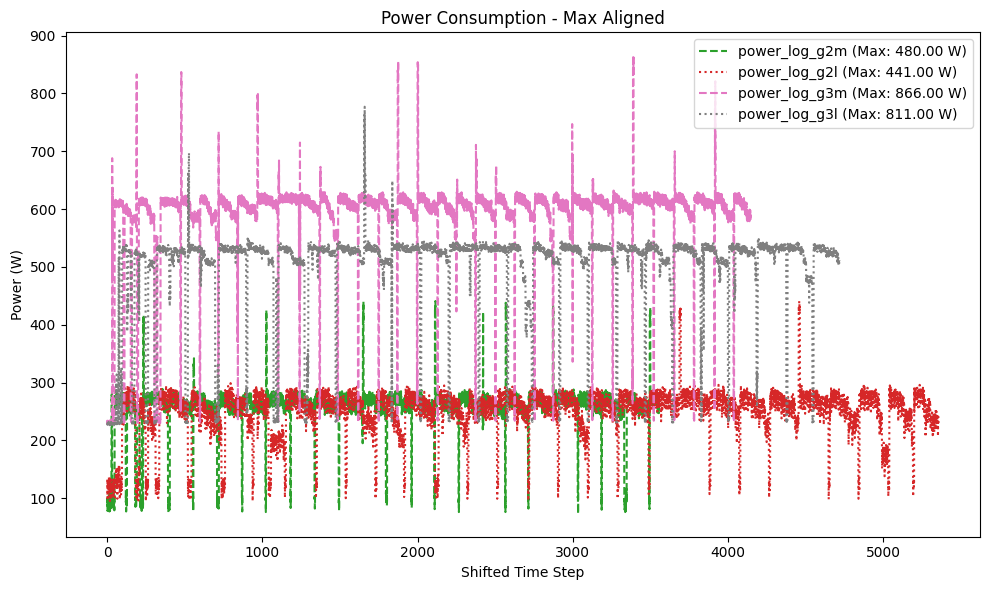

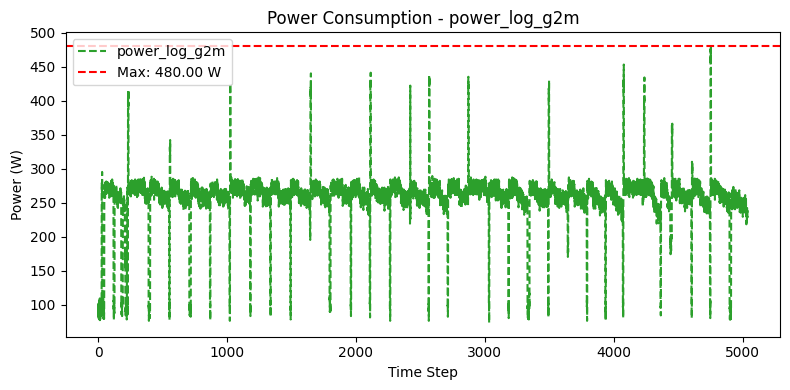

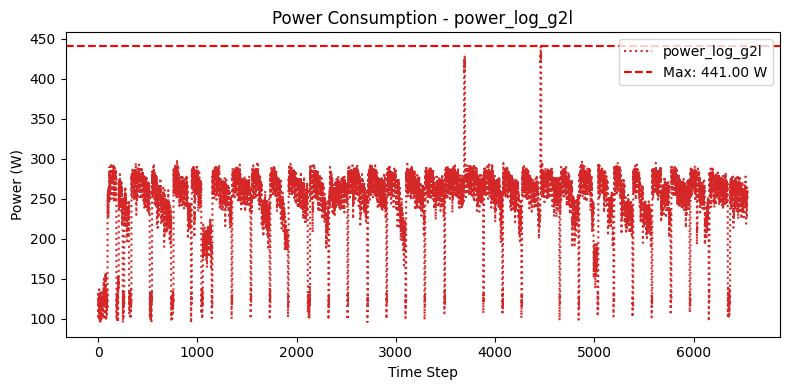

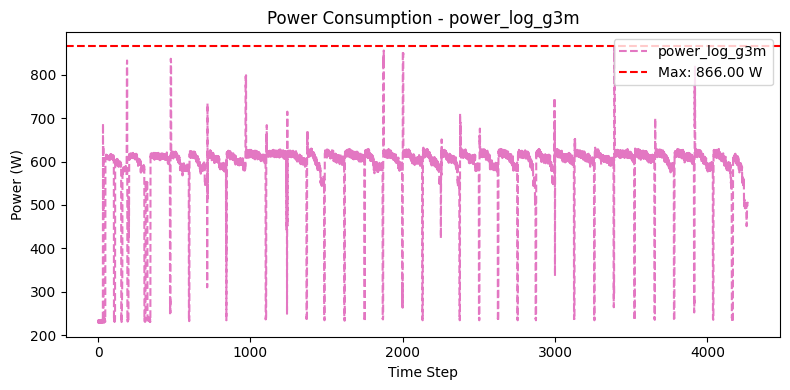

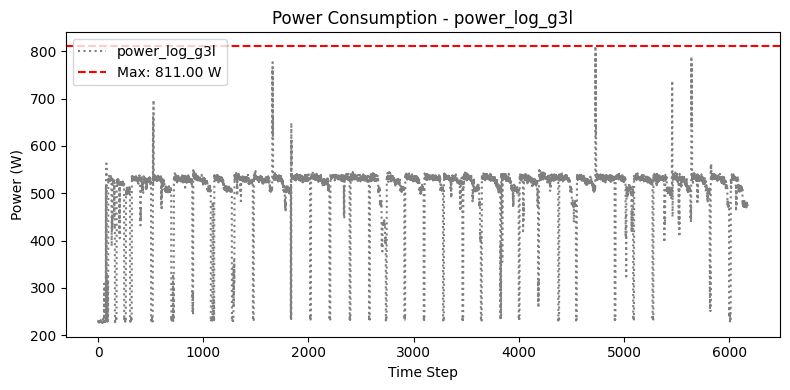


=== Max Power Consumption ===
power_log_g2m: 480.00 W
power_log_g2l: 441.00 W
power_log_g3m: 866.00 W
power_log_g3l: 811.00 W


In [ ]:
import matplotlib.pyplot as plt

# ===== PLOT: ORIGINAL =====
plt.figure(figsize=(10, 6))
for run in sorted_runs:
    cfg_key = meta_info[run][2]  # normalized config like '2', '2s', etc.
    plt.plot(
        data_dict[run],
        label=f"{run} (Max: {max_values[run]:.2f} W)",
        color=color_map.get(cfg_key, "black"),
        linestyle=style_map.get(meta_info[run][1], "-")
    )
plt.title("Power Consumption - All Runs (Original Alignment)")
plt.xlabel("Time Step")
plt.ylabel("Power (W)")
plt.legend()
plt.tight_layout()
plt.show()

# ===== PLOT: MAX ALIGNED =====
plt.figure(figsize=(10, 6))
for run in sorted_runs:
    cfg_key = meta_info[run][2]
    plt.plot(
        max_aligned_data[run],
        label=f"{run} (Max: {max_values[run]:.2f} W)",
        color=color_map.get(cfg_key, "black"),
        linestyle=style_map.get(meta_info[run][1], "-")
    )
plt.title("Power Consumption - Max Aligned")
plt.xlabel("Shifted Time Step")
plt.ylabel("Power (W)")
plt.legend()
plt.tight_layout()
plt.show()

# ===== INDIVIDUAL PLOTS =====
for run in sorted_runs:
    cfg_key = meta_info[run][2]
    plt.figure(figsize=(8, 4))
    plt.plot(
        data_dict[run],
        color=color_map.get(cfg_key, "black"),
        linestyle=style_map.get(meta_info[run][1], "-"),
        label=run
    )
    plt.axhline(max_values[run], color='red', linestyle='--',
                label=f"Max: {max_values[run]:.2f} W")
    plt.title(f"Power Consumption - {run}")
    plt.xlabel("Time Step")
    plt.ylabel("Power (W)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ===== PRINT MAX VALUES =====
print("\n=== Max Power Consumption ===")
for run in sorted_runs:
    print(f"{run}: {max_values[run]:.2f} W")


=== Max Power Consumption ===
power_log_g2m: 480.00 W
power_log_g2l: 441.00 W
power_log_g3m: 866.00 W
power_log_g3l: 811.00 W


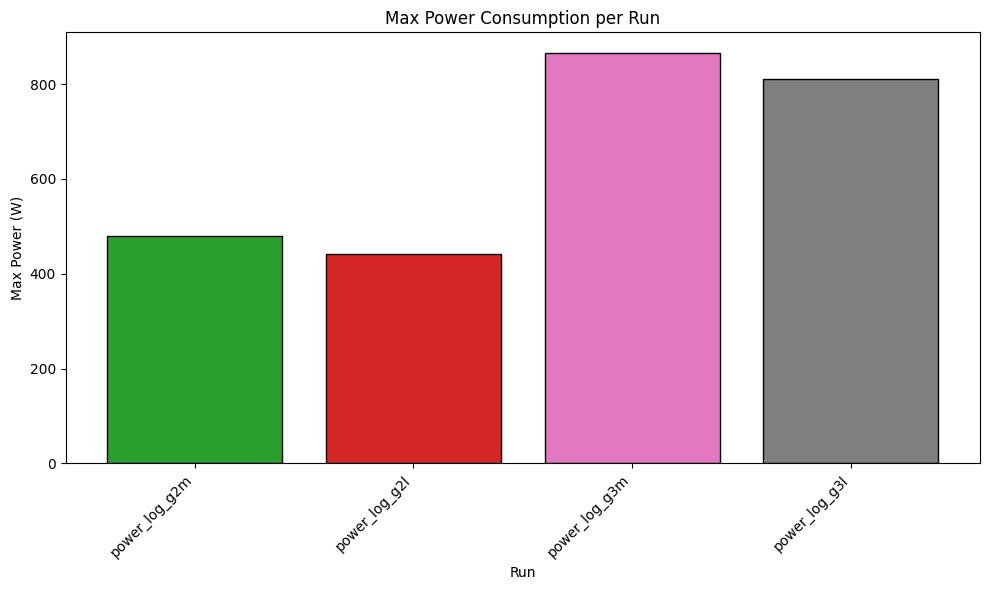

In [ ]:
# ===== PRINT MAX VALUES =====
print("\n=== Max Power Consumption ===")
for run in sorted_runs:
    print(f"{run}: {max_values[run]:.2f} W")

# ===== HISTOGRAM OF MAX VALUES =====
plt.figure(figsize=(10, 6))
bars = []
labels = []
colors = []

for run in sorted_runs:
    cfg_key = meta_info[run][2]  # normalized config
    bars.append(max_values[run])
    labels.append(run)
    colors.append(color_map.get(cfg_key, "black"))

plt.bar(labels, bars, color=colors, edgecolor="black")
plt.title("Max Power Consumption per Run")
plt.xlabel("Run")
plt.ylabel("Max Power (W)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Power Consumption Analysis

In [ ]:
import pandas as pd
import glob
import os
import numpy as np

# ===== SETTINGS =====
DATA_DIR = "./power_logs"  # Directory containing power log CSVs

# ===== LOAD DATA =====
csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
data_dict = {}
run_durations = {}

for file in csv_files:
    df = pd.read_csv(file)

    # Find power column
    power_col = None
    for col in df.columns:
        if "power" in col.lower():
            power_col = col
            break
    if power_col is None:
        print(f"⚠️ No power column found in {file}, skipping...")
        continue

    run_name = os.path.splitext(os.path.basename(file))[0]

    # Clean power values
    power_values = (
        df[power_col]
        .astype(str)
        .str.strip()
        .str.replace("W", "", regex=False)
        .str.replace("w", "", regex=False)
        .astype(float)
        .dropna()
        .to_numpy()
    )
    data_dict[run_name] = power_values

    # Process timestamps for actual duration
    timestamp_col = None
    for col in df.columns:
        if "timestamp" in col.lower():
            timestamp_col = col
            break

    if timestamp_col is not None and not df[timestamp_col].empty:
        # Remove unrecognized timezone abbreviations before parsing to avoid FutureWarnings
        # Example: 'Thu Mar 26 20:15:17 IST 2026' -> 'Thu Mar 26 20:15:17 2026'
        cleaned_timestamp_series = df[timestamp_col].astype(str).str.replace(r'\s[A-Z]{3}\s', ' ', regex=True)
        df['parsed_timestamp'] = pd.to_datetime(cleaned_timestamp_series, errors='coerce')
        df_valid_timestamps = df.dropna(subset=['parsed_timestamp'])

        if not df_valid_timestamps.empty:
            start_time = df_valid_timestamps['parsed_timestamp'].min()
            end_time = df_valid_timestamps['parsed_timestamp'].max()
            duration = end_time - start_time
            run_durations[run_name] = duration
        else:
            run_durations[run_name] = pd.Timedelta(seconds=0) # No valid timestamps
            print(f"⚠️ No valid timestamps found in {file}")
    else:
        run_durations[run_name] = pd.Timedelta(seconds=0) # No timestamp column or empty
        print(f"⚠️ Timestamp column not found or empty in {file}")

# ===== POWER CONSUMPTION ANALYSIS =====
print("\n=== Power Consumption Analysis ===")

for run, power_values in data_dict.items():
    average_power = np.mean(power_values)
    total_power_consumption_watt_samples = np.sum(power_values)
    total_time_samples = len(power_values)
    actual_time_taken = run_durations.get(run, pd.Timedelta(seconds=0))

    print(f"\nRun: {run}")
    print(f"  Average Power Consumption: {average_power:.2f} W")
    print(f"  Total Power Consumption (Watt-samples): {total_power_consumption_watt_samples:.2f}")
    print(f"  Total Time Taken (samples): {total_time_samples}")
    print(f"  Actual Elapsed Time: {actual_time_taken}")


=== Power Consumption Analysis ===

Run: power_log_g2m
  Average Power Consumption: 258.96 W
  Total Power Consumption (Watt-samples): 1305180.00
  Total Time Taken (samples): 5040
  Actual Elapsed Time: 0 days 00:21:00

Run: power_log_g2l
  Average Power Consumption: 251.04 W
  Total Power Consumption (Watt-samples): 1642787.00
  Total Time Taken (samples): 6544
  Actual Elapsed Time: 0 days 00:13:37

Run: power_log_g3l
  Average Power Consumption: 504.95 W
  Total Power Consumption (Watt-samples): 3118599.00
  Total Time Taken (samples): 6176
  Actual Elapsed Time: 0 days 00:12:51

Run: power_log_g3m
  Average Power Consumption: 589.87 W
  Total Power Consumption (Watt-samples): 2515190.00
  Total Time Taken (samples): 4264
  Actual Elapsed Time: 0 days 00:17:45


In [ ]:
g2='''

'''

g2_l: Max Prompt Throughput = 122.5 tokens/s, Max Generation Throughput = 667.4 tokens/s
g2_m: Max Prompt Throughput = 122.5 tokens/s, Max Generation Throughput = 413.2 tokens/s
g3_l: Max Prompt Throughput = 122.7 tokens/s, Max Generation Throughput = 674.6 tokens/s
g3_m: Max Prompt Throughput = 122.4 tokens/s, Max Generation Throughput = 485.4 tokens/s


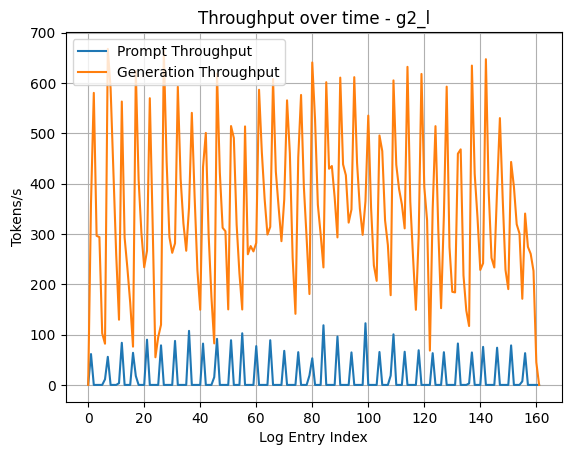

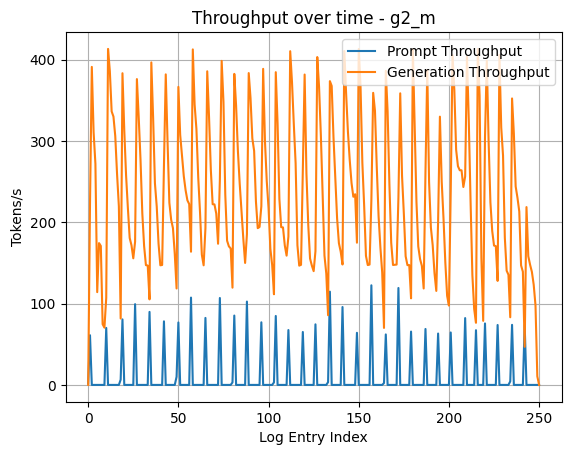

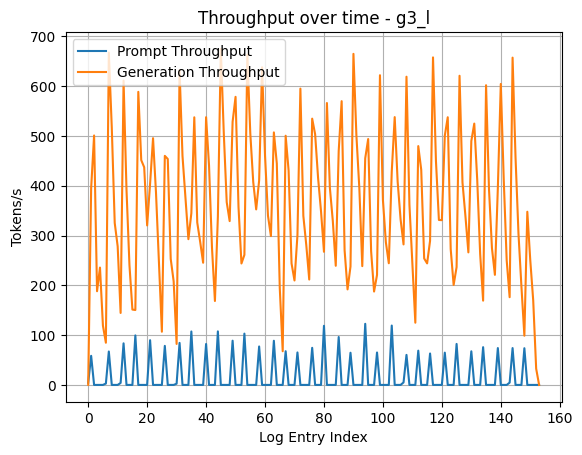

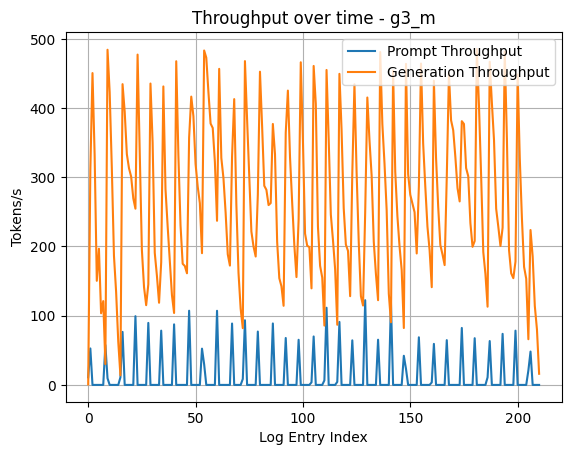

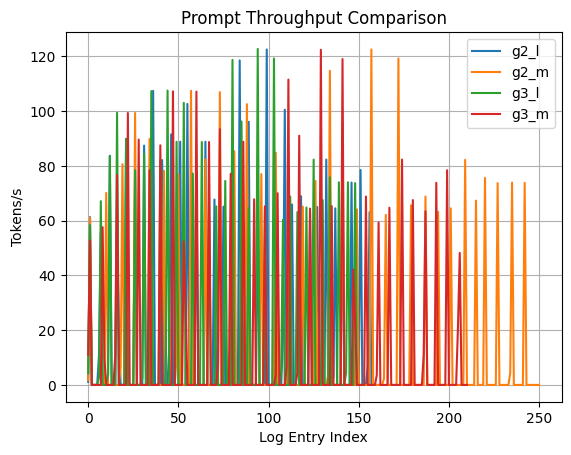

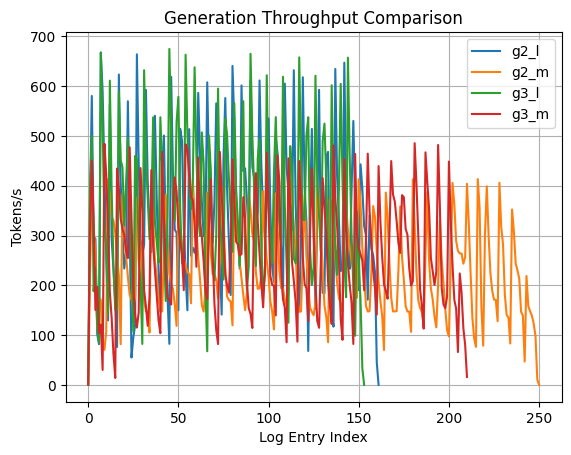

In [ ]:
import re
import matplotlib.pyplot as plt



# Store all in a dict for processing
log_data = {
    "g2_l": g2l,
    "g2_m": g2m, "g3_l": g3l,  "g3_m": g3m,
}

pattern = re.compile(
    r"Avg prompt throughput: ([\d\.]+) tokens/s, Avg generation throughput: ([\d\.]+) tokens/s"
)

results = {}

for name, text in log_data.items():
    prompt_vals = []
    gen_vals = []

    for match in pattern.finditer(text):
        prompt_vals.append(float(match.group(1)))
        gen_vals.append(float(match.group(2)))

    if prompt_vals and gen_vals:
        results[name] = {
            "prompt_vals": prompt_vals,
            "gen_vals": gen_vals,
            "max_prompt": max(prompt_vals),
            "max_gen": max(gen_vals),
        }

# Print max values
for name, vals in results.items():
    print(f"{name}: Max Prompt Throughput = {vals['max_prompt']} tokens/s, "
          f"Max Generation Throughput = {vals['max_gen']} tokens/s")

# --- Plot individual graphs ---
for name, vals in results.items():
    plt.figure()
    plt.plot(vals["prompt_vals"], label="Prompt Throughput")
    plt.plot(vals["gen_vals"], label="Generation Throughput")
    plt.title(f"Throughput over time - {name}")
    plt.xlabel("Log Entry Index")
    plt.ylabel("Tokens/s")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Comparative plots ---
# Prompt throughput comparison
plt.figure()
for name, vals in results.items():
    plt.plot(vals["prompt_vals"], label=name)
plt.title("Prompt Throughput Comparison")
plt.xlabel("Log Entry Index")
plt.ylabel("Tokens/s")
plt.legend()
plt.grid(True)
plt.show()

# Generation throughput comparison
plt.figure()
for name, vals in results.items():
    plt.plot(vals["gen_vals"], label=name)
plt.title("Generation Throughput Comparison")
plt.xlabel("Log Entry Index")
plt.ylabel("Tokens/s")
plt.legend()
plt.grid(True)
plt.show()


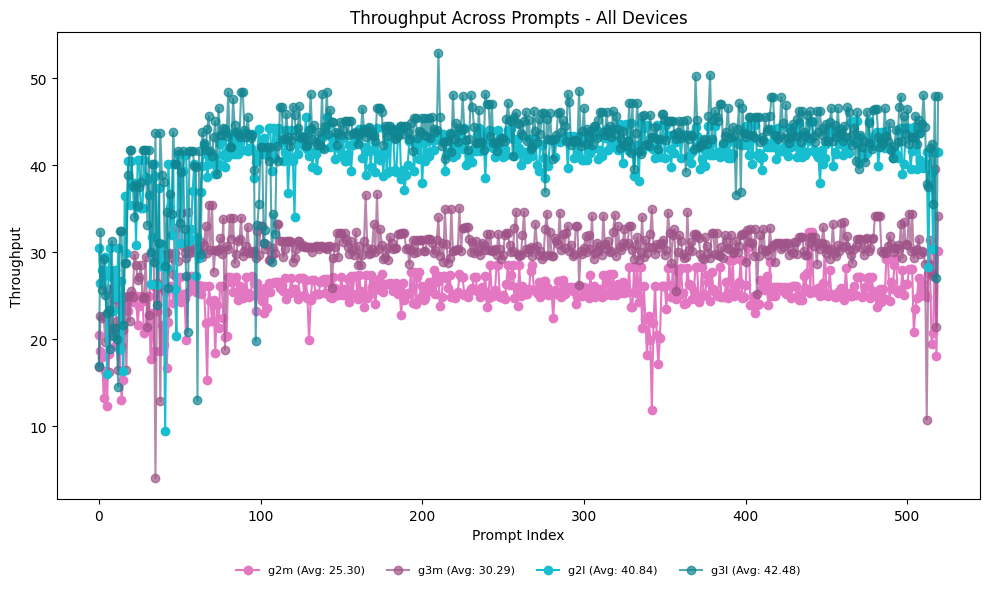

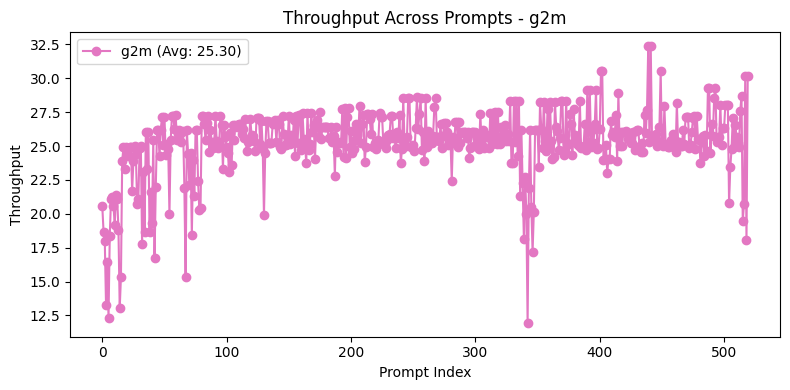

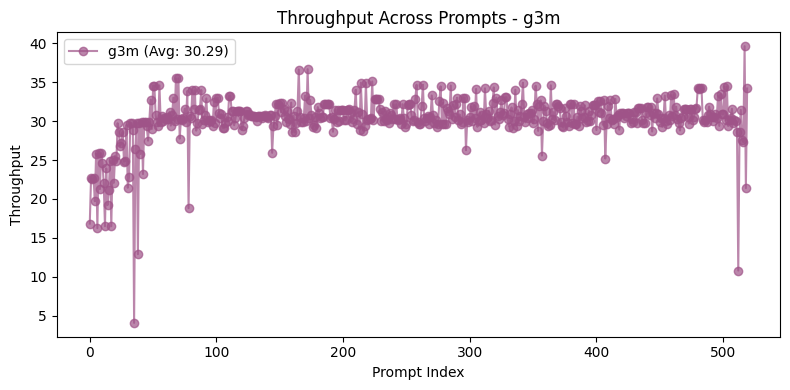

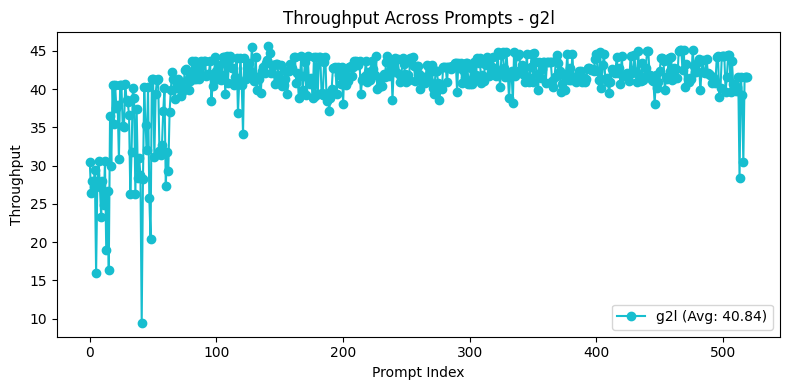

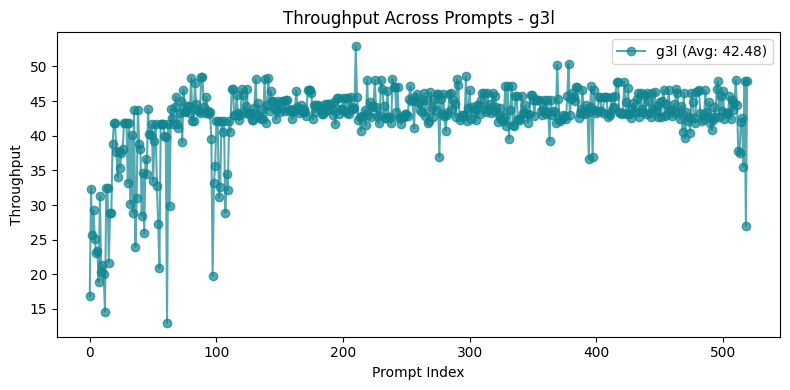

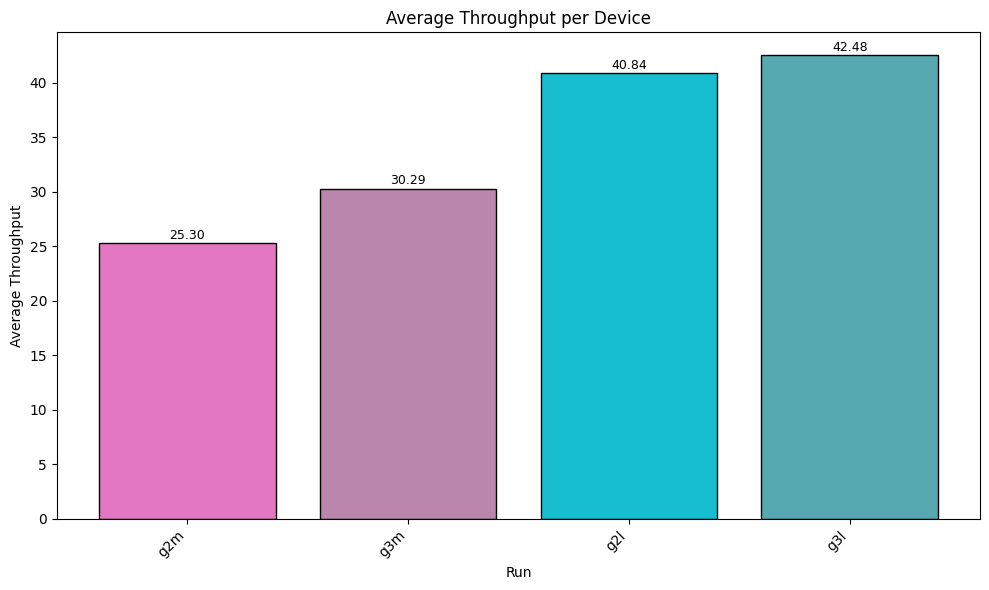

In [ ]:
import matplotlib.cm as cm
import numpy as np
import matplotlib.pyplot as plt

# ===== CUSTOM ORDER FOR G2/G3 ALTERNATING =====
bench_plot_order = ["2", "3", "2s", "3s", "2m", "3m", "2l", "3l"]

def get_cfg_key(run_name):
    # Extract config like "2", "3", "2s", "3m" from filename
    return run_name.split("_")[-1].replace("g", "")  # remove "g" if present

bench_sorted_runs = sorted(
    bench_data.keys(),
    key=lambda x: bench_plot_order.index(get_cfg_key(x)) if get_cfg_key(x) in bench_plot_order else 999
)

# ===== COLOR ASSIGNMENT: SAME BASE FOR G2 & G3 =====
base_configs = ["2", "2s", "2m", "2l"]  # Only for color grouping
base_color_list = cm.tab10(np.linspace(0, 1, len(base_configs)))  # Base palette
bench_color_map = {}

for run in bench_sorted_runs:
    cfg = get_cfg_key(run)  # e.g., '2', '3', '2s', '3s'
    base_cfg = cfg.replace("3", "2")  # Map g3 variants to g2 color
    if base_cfg not in base_configs:
        base_cfg = base_configs[0]  # fallback if weird name
    base_idx = base_configs.index(base_cfg)
    if cfg.startswith("2"):
        bench_color_map[run] = base_color_list[base_idx]
    else:  # g3 variant → darker shade of same base color
        bench_color_map[run] = tuple(np.array(base_color_list[base_idx]) * 0.7)

# ===== PLOT: ALL DEVICES THROUGHPUT =====
plt.figure(figsize=(10, 6))
for run in bench_sorted_runs:
    plt.plot(
        bench_data[run],
        marker='o',
        label=f"{run} (Avg: {bench_throughput[run]:.2f})",
        color=bench_color_map[run],
        linestyle="-"
    )
plt.title("Throughput Across Prompts - All Devices")
plt.xlabel("Prompt Index")
plt.ylabel("Throughput")

# Smaller legend outside the plot
plt.legend(
    fontsize=8,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=4,
    frameon=False
)

plt.tight_layout()
plt.show()


# ===== INDIVIDUAL THROUGHPUT PLOTS =====
for run in bench_sorted_runs:
    plt.figure(figsize=(8, 4))
    plt.plot(
        bench_data[run],
        marker='o',
        color=bench_color_map[run],
        linestyle="-",
        label=f"{run} (Avg: {bench_throughput[run]:.2f})"
    )
    plt.title(f"Throughput Across Prompts - {run}")
    plt.xlabel("Prompt Index")
    plt.ylabel("Throughput")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ===== HISTOGRAM OF AVG THROUGHPUT =====
plt.figure(figsize=(10, 6))
bars = [bench_throughput[run] for run in bench_sorted_runs]
labels = [run for run in bench_sorted_runs]
colors = [bench_color_map[run] for run in bench_sorted_runs]

plt.bar(labels, bars, color=colors, edgecolor="black")
for i, val in enumerate(bars):
    plt.text(i, val + 0.1, f"{val:.2f}", ha="center", va="bottom", fontsize=9)
plt.title("Average Throughput per Device")
plt.xlabel("Run")
plt.ylabel("Average Throughput")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

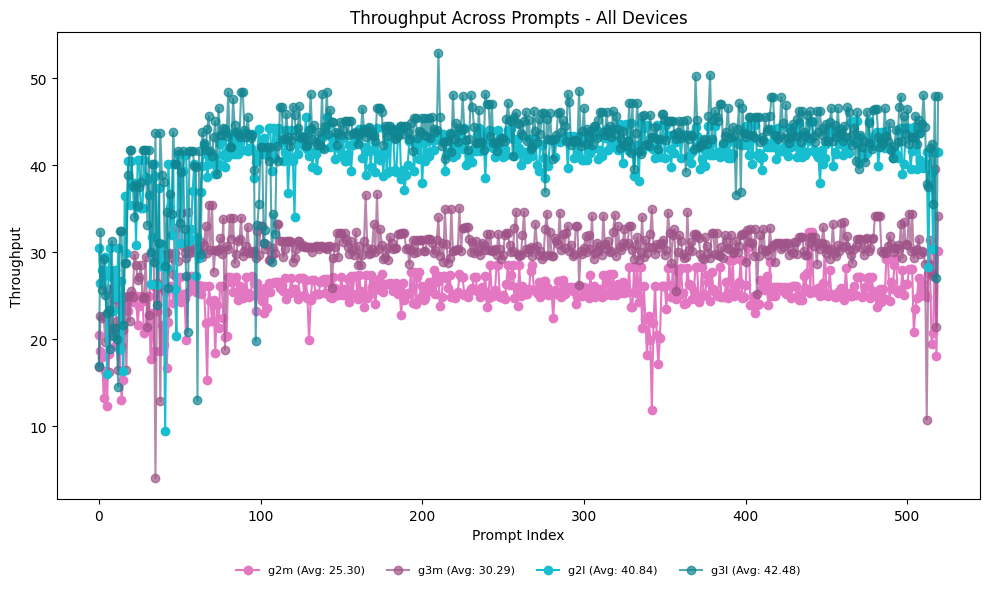

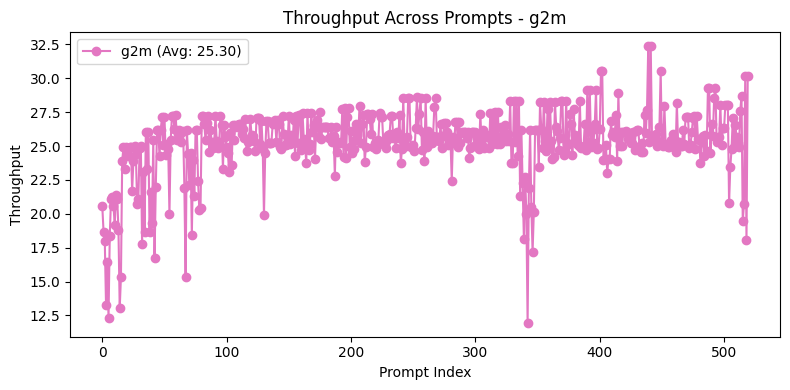

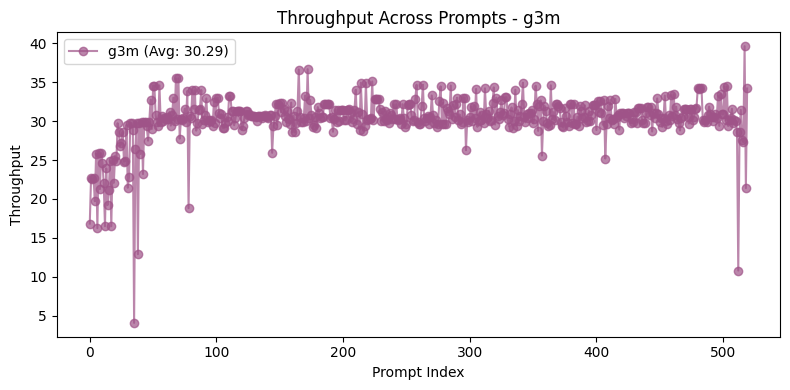

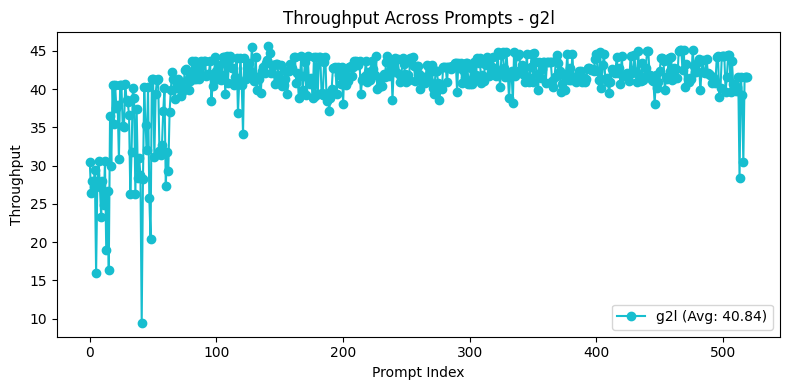

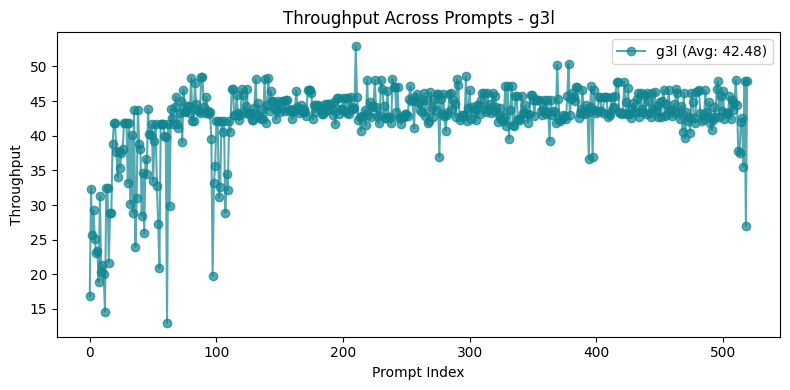

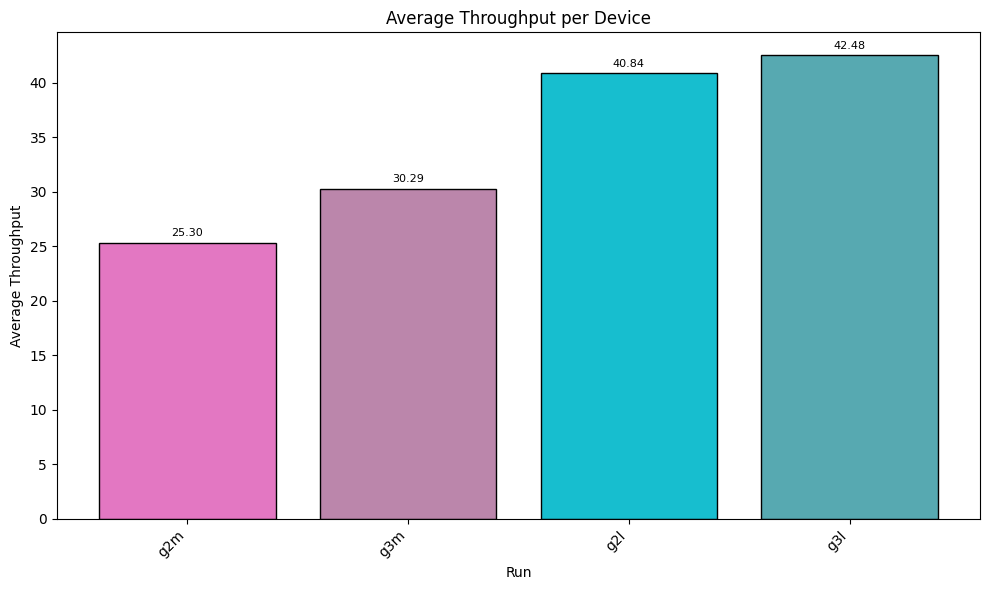

In [ ]:
import matplotlib.cm as cm
import numpy as np
import matplotlib.pyplot as plt

# ===== CUSTOM ORDER FOR G2/G3 ALTERNATING =====
bench_plot_order = ["2", "3", "2s", "3s", "2m", "3m", "2l", "3l"]

def get_cfg_key(run_name):
    # Extract config like "2", "3", "2s", "3m" from filename
    return run_name.split("_")[-1].replace("g", "")  # remove "g" if present

bench_sorted_runs = sorted(
    bench_data.keys(),
    key=lambda x: bench_plot_order.index(get_cfg_key(x)) if get_cfg_key(x) in bench_plot_order else 999
)

# ===== COLOR ASSIGNMENT: SAME BASE FOR G2 & G3 =====
base_configs = ["2", "2s", "2m", "2l"]  # Only for color grouping
base_color_list = cm.tab10(np.linspace(0, 1, len(base_configs)))  # Base palette
bench_color_map = {}

for run in bench_sorted_runs:
    cfg = get_cfg_key(run)  # e.g., '2', '3', '2s', '3s'
    base_cfg = cfg.replace("3", "2")  # Map g3 variants to g2 color
    if base_cfg not in base_configs:
        base_cfg = base_configs[0]  # fallback if weird name
    base_idx = base_configs.index(base_cfg)
    if cfg.startswith("2"):
        bench_color_map[run] = base_color_list[base_idx]
    else:  # g3 variant → darker shade of same base color
        bench_color_map[run] = tuple(np.array(base_color_list[base_idx]) * 0.7)

# ===== PLOT: ALL DEVICES THROUGHPUT =====
plt.figure(figsize=(10, 6))
for run in bench_sorted_runs:
    plt.plot(
        bench_data[run],  # Use bench_data[run] directly
        marker='o',
        label=f"{run} (Avg: {bench_throughput[run]:.2f})",
        color=bench_color_map[run],
        linestyle="-"
    )
plt.title("Throughput Across Prompts - All Devices")
plt.xlabel("Prompt Index")
plt.ylabel("Throughput")
plt.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False)
plt.tight_layout()
plt.show()

# ===== INDIVIDUAL THROUGHPUT PLOTS =====
for run in bench_sorted_runs:
    plt.figure(figsize=(8, 4))
    plt.plot(
        bench_data[run], # Use bench_data[run] directly
        marker='o',
        color=bench_color_map[run],
        linestyle="-",
        label=f"{run} (Avg: {bench_throughput[run]:.2f})"
    )
    plt.title(f"Throughput Across Prompts - {run}")
    plt.xlabel("Prompt Index")
    plt.ylabel("Throughput")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ===== HISTOGRAMS FOR ALL METRICS =====
# Assuming bench_data contains only throughput for now based on the error
metrics = ["throughput"]

for metric in metrics:
    plt.figure(figsize=(10, 6))
    # Use bench_throughput which already contains the average throughput
    avg_values = [bench_throughput[run] for run in bench_sorted_runs]
    plt.bar(bench_sorted_runs, avg_values, color=[bench_color_map[run] for run in bench_sorted_runs], edgecolor="black")
    for i, val in enumerate(avg_values):
        plt.text(i, val + 0.01 * max(avg_values), f"{val:.2f}", ha="center", va="bottom", fontsize=8)
    plt.title(f"Average Throughput per Device") # Updated title
    plt.xlabel("Run")
    plt.ylabel(f"Average Throughput") # Updated ylabel
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()

    plt.show()

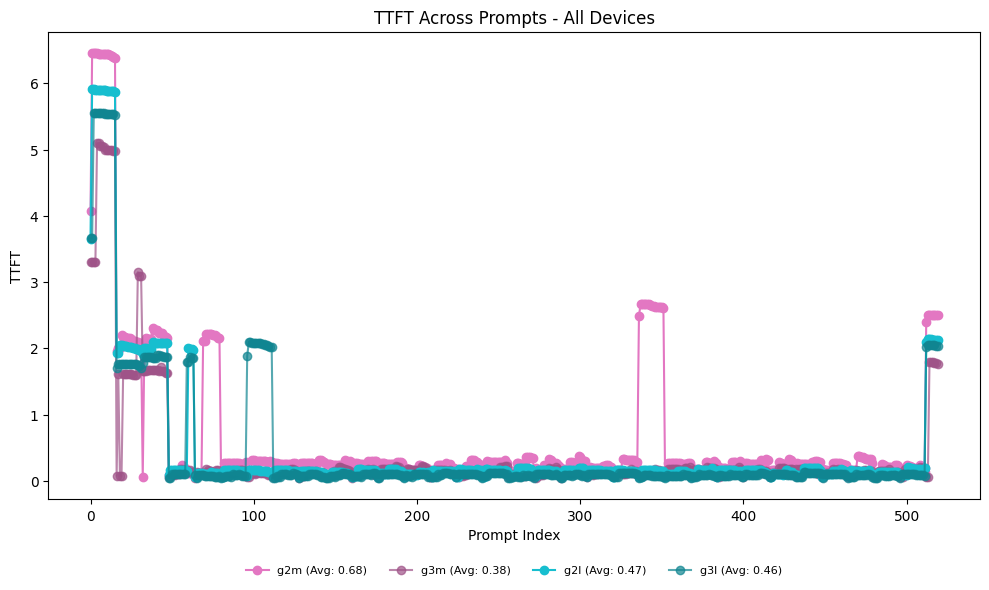

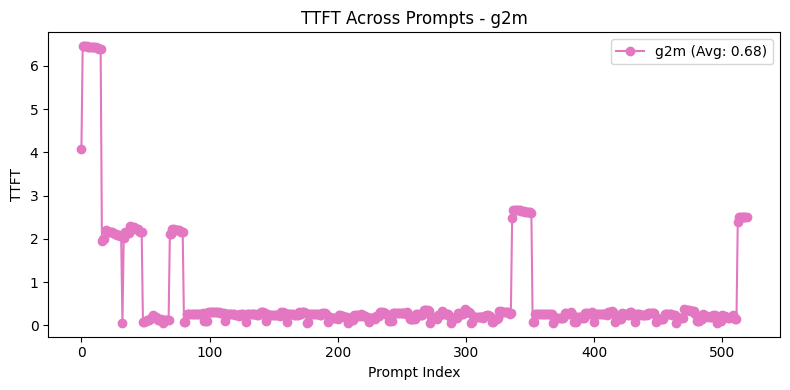

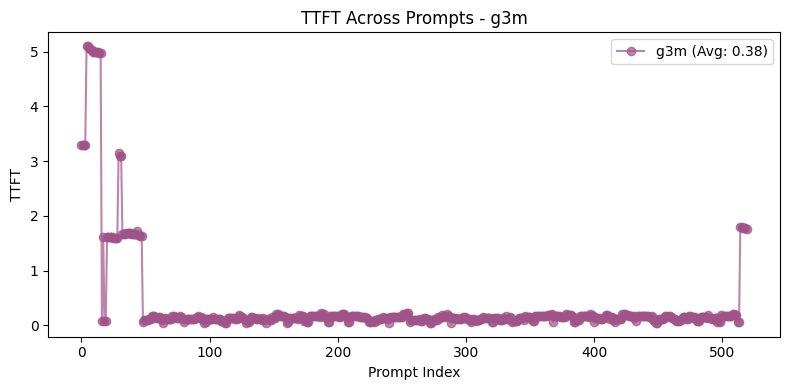

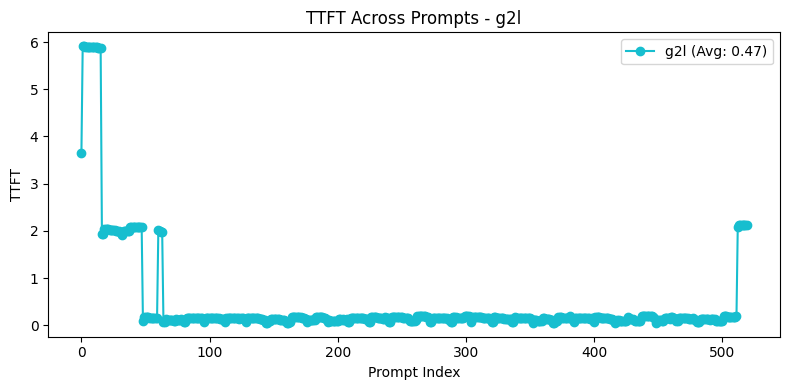

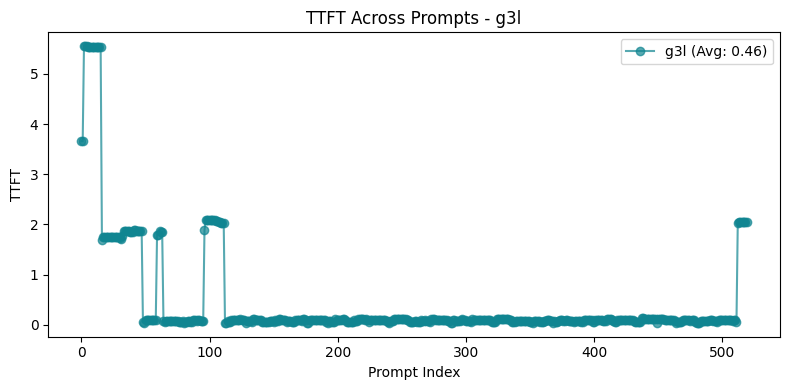

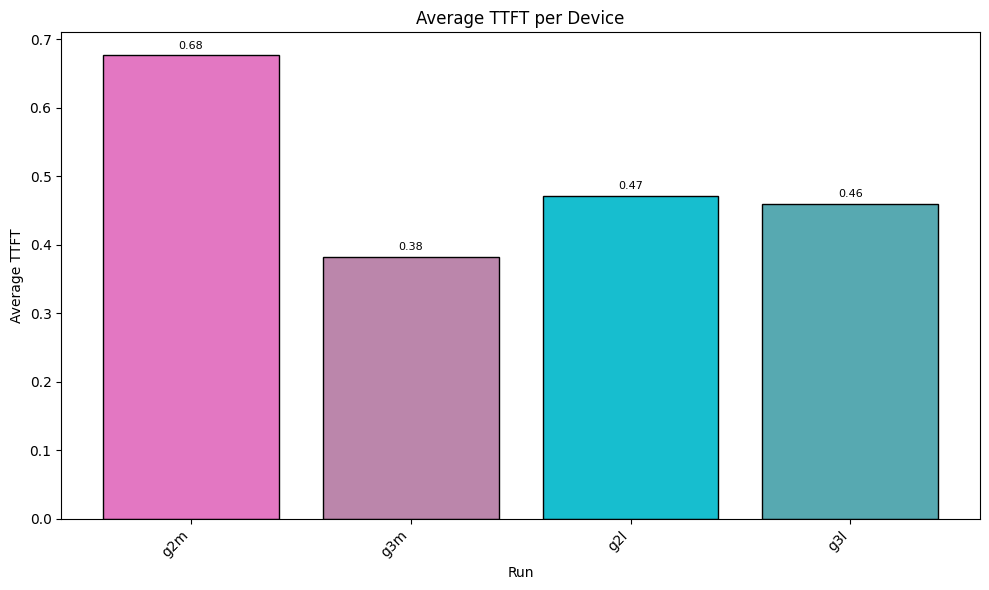

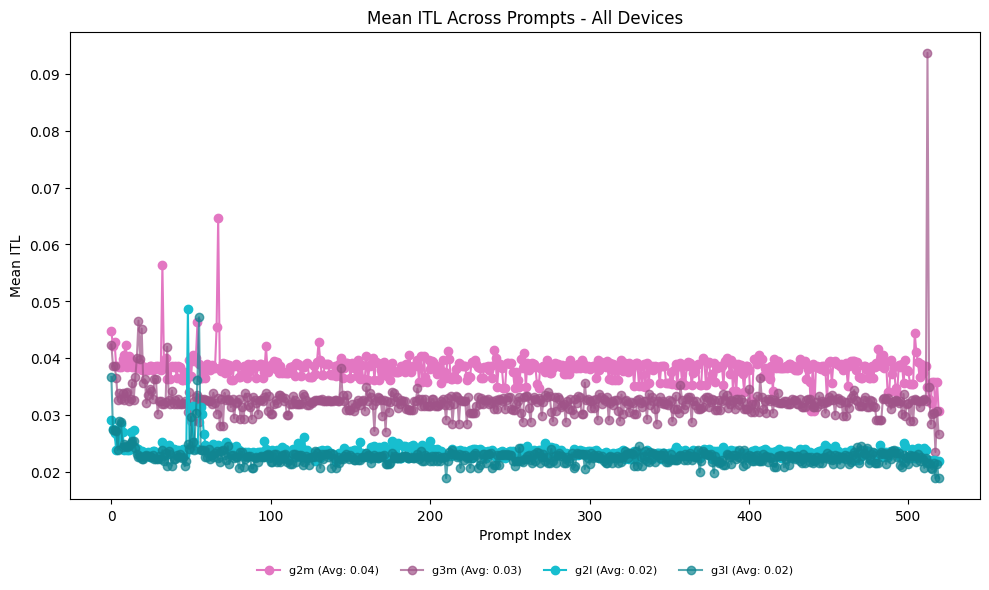

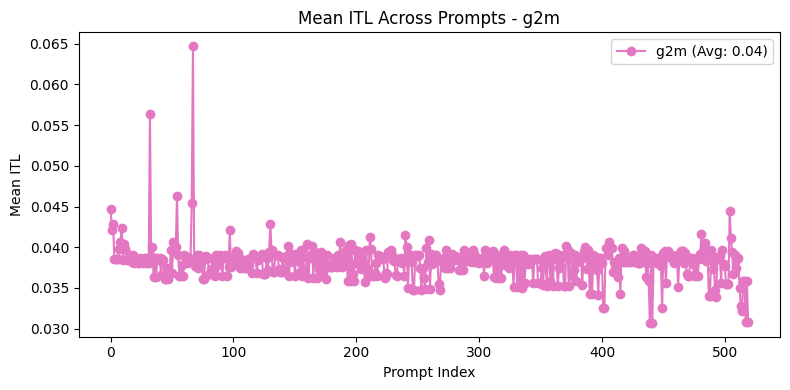

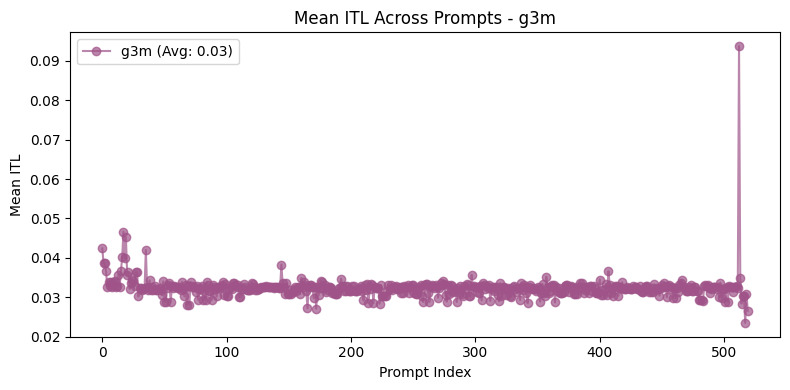

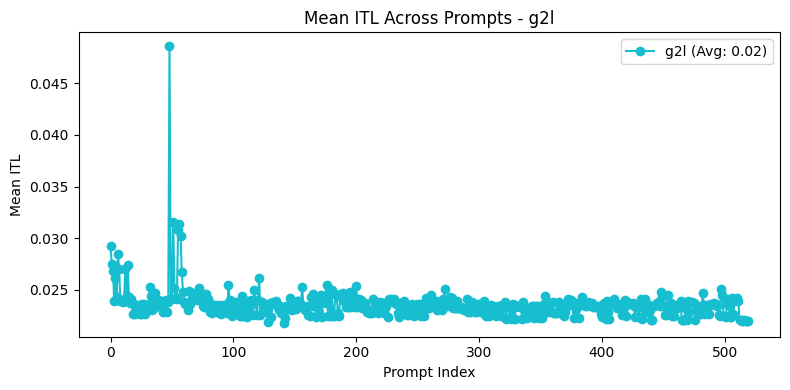

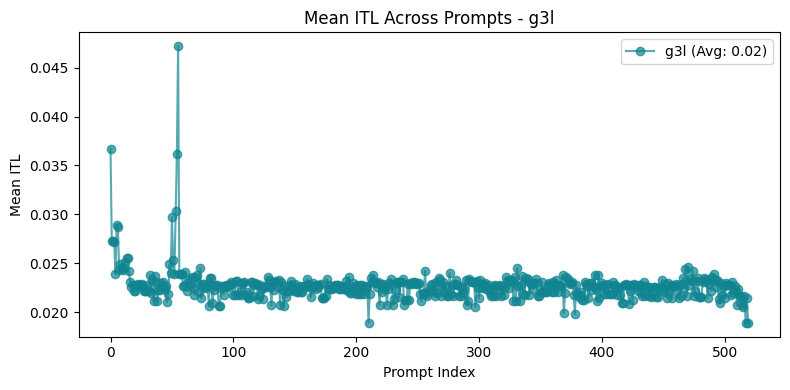

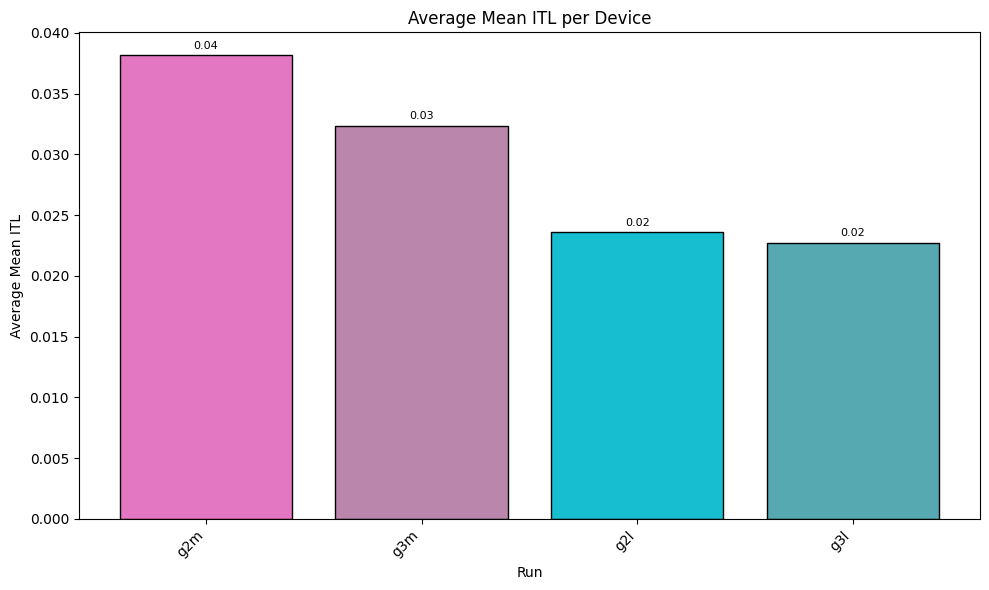

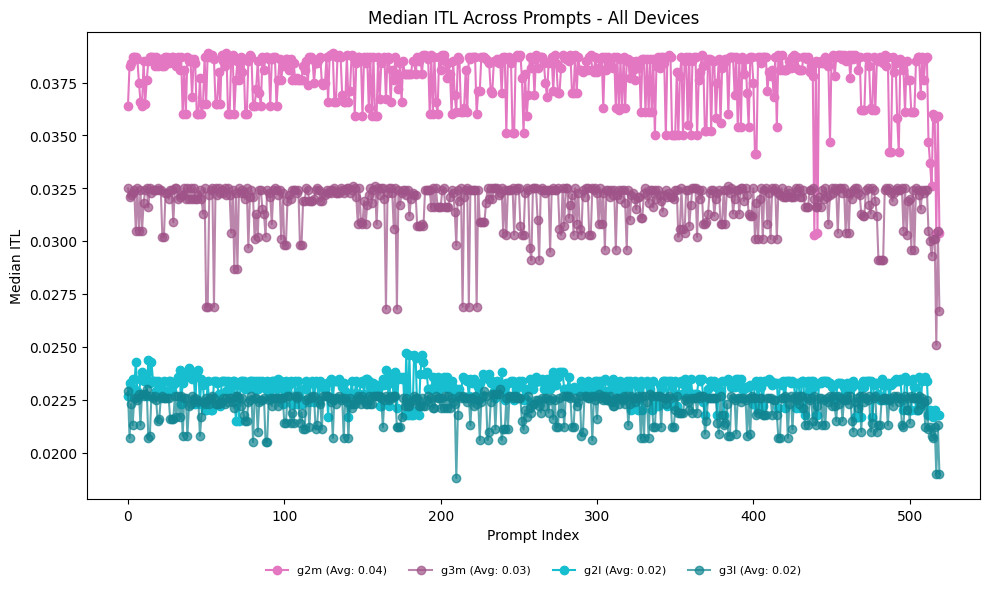

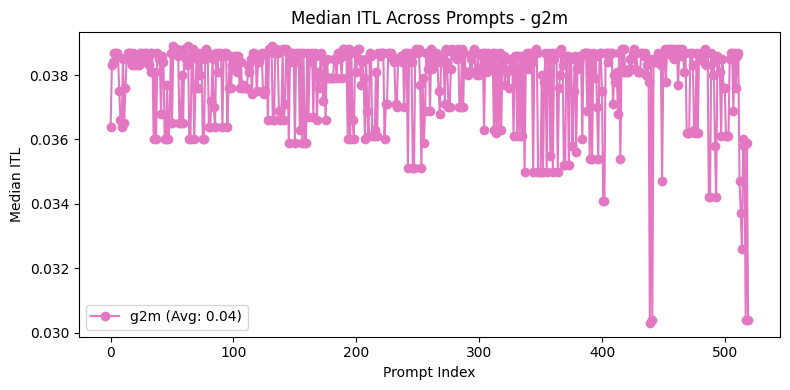

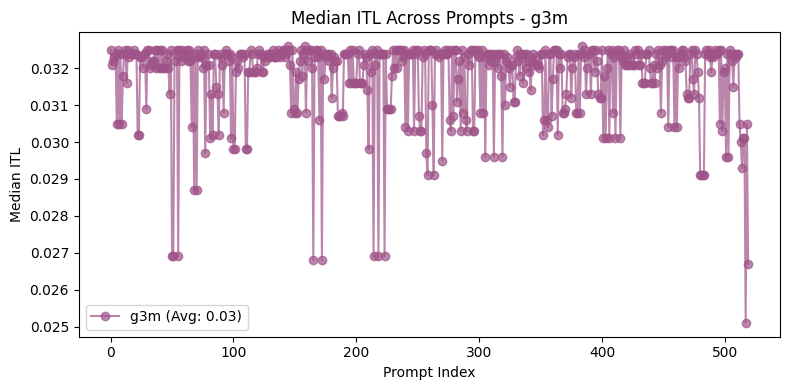

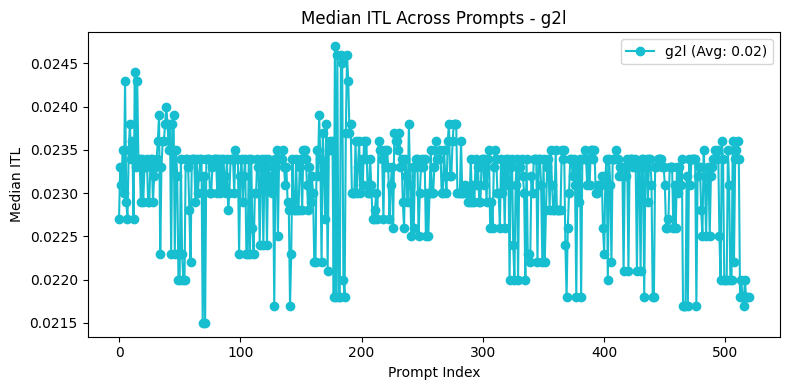

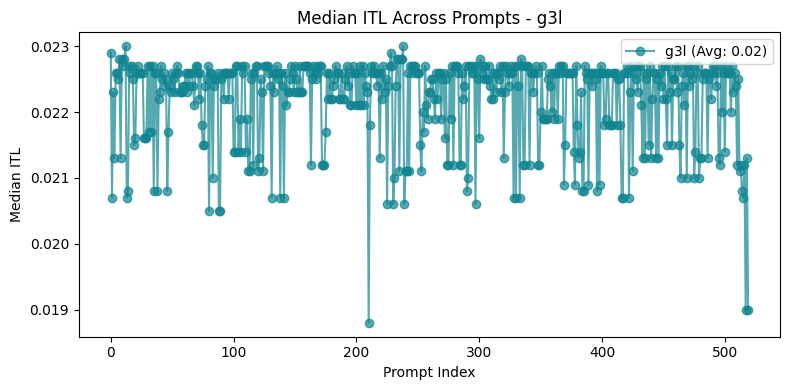

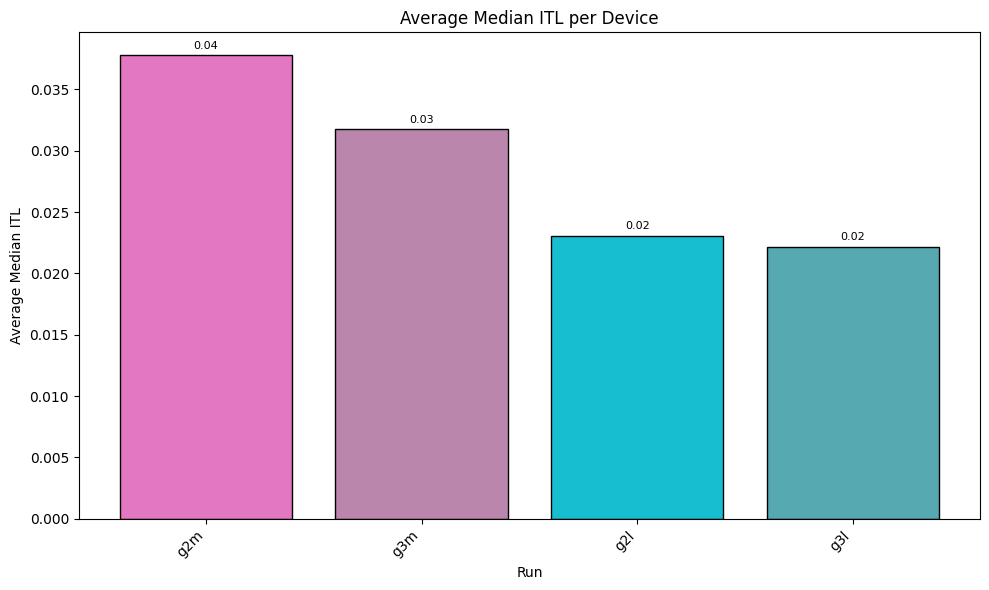

In [ ]:
# Call the function for TTFT
plot_benchmark_metric("TTFT", bench_ttft_data, bench_ttft)

# Call the function for Mean ITL
plot_benchmark_metric("Mean ITL", bench_mean_itl_data, bench_mean_itl)

# Call the function for Median ITL
plot_benchmark_metric("Median ITL", bench_median_itl_data, bench_median_itl)

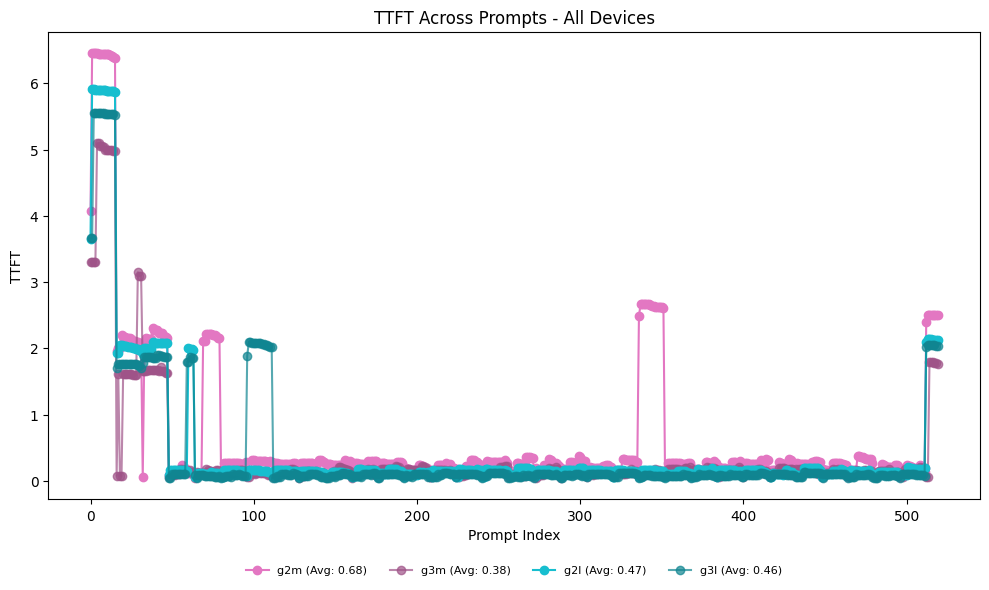

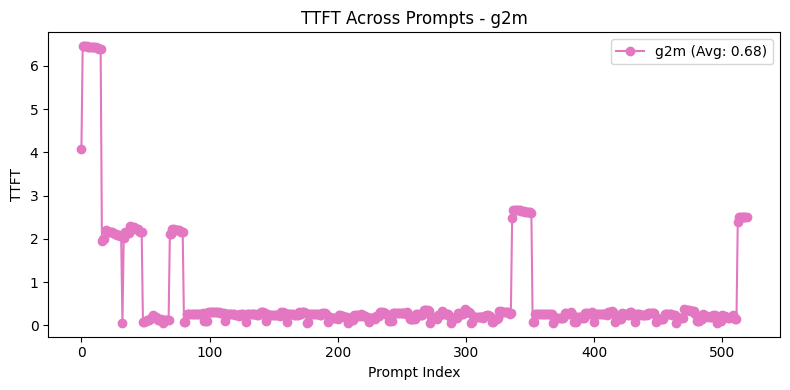

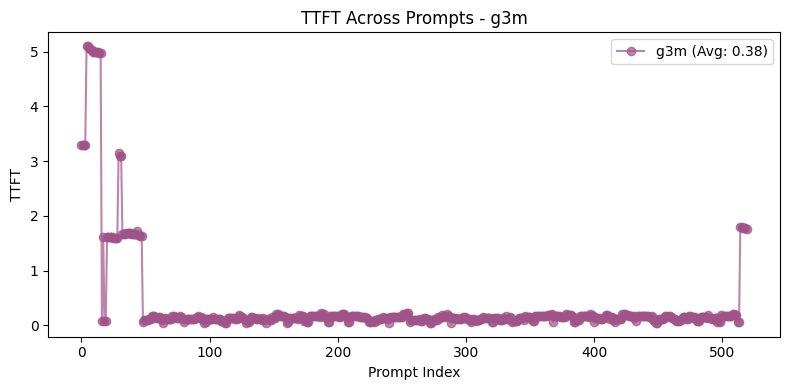

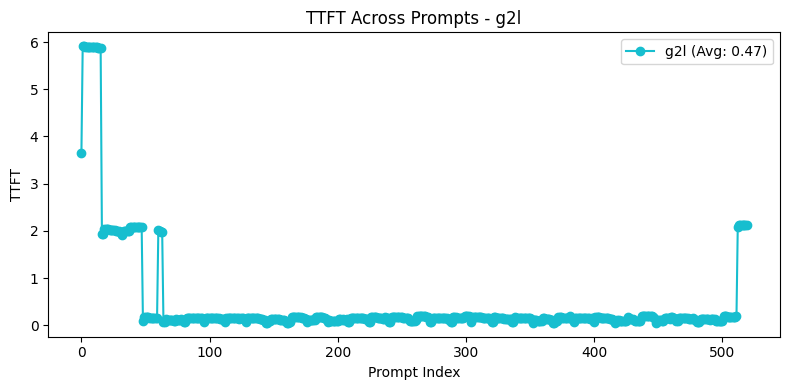

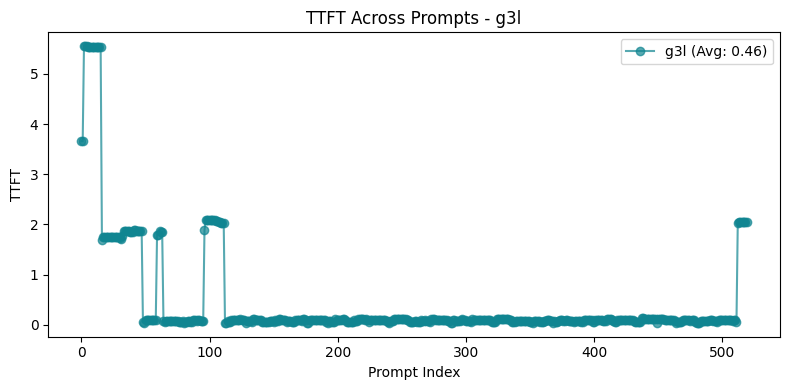

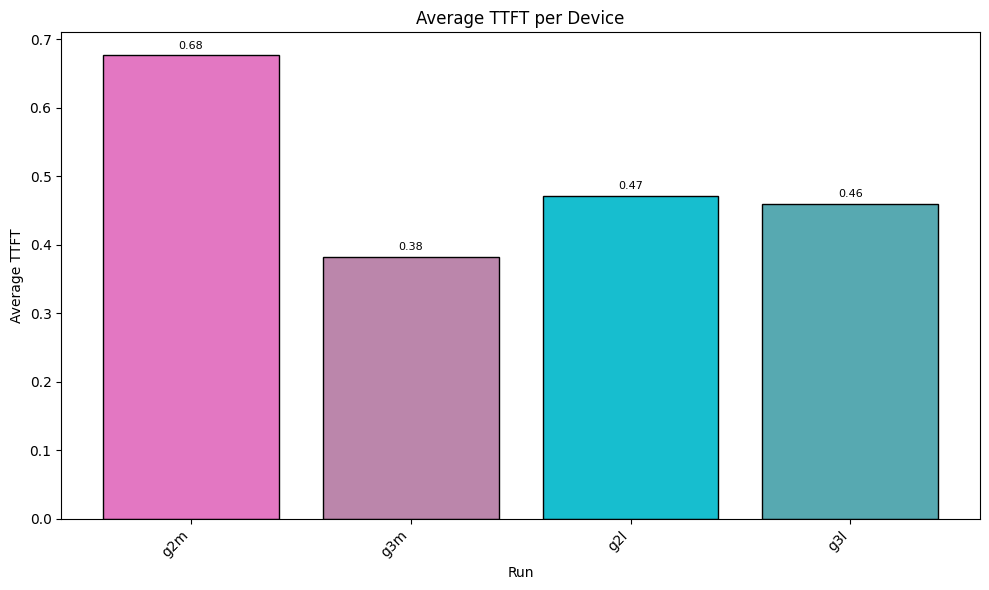

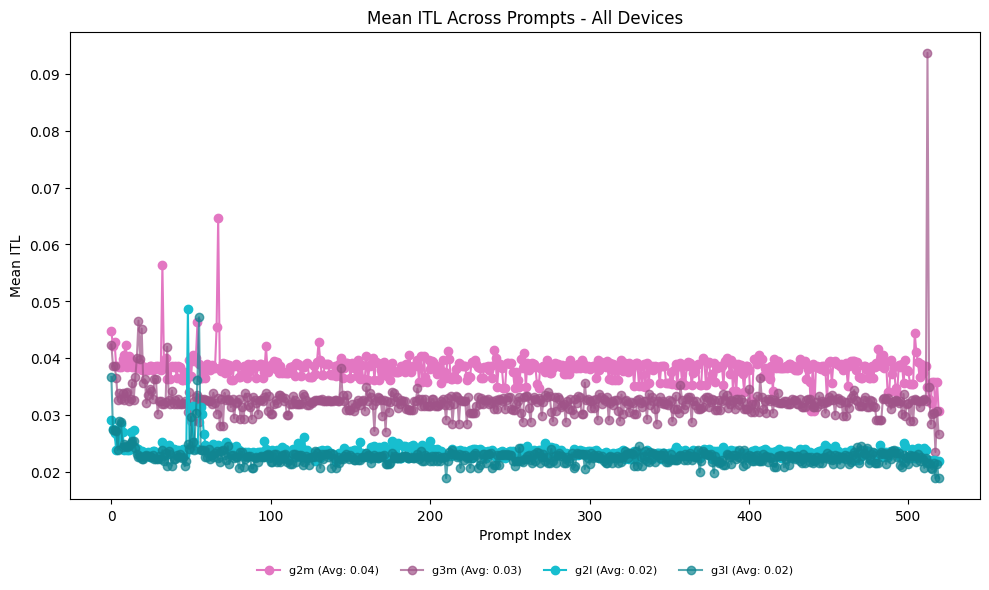

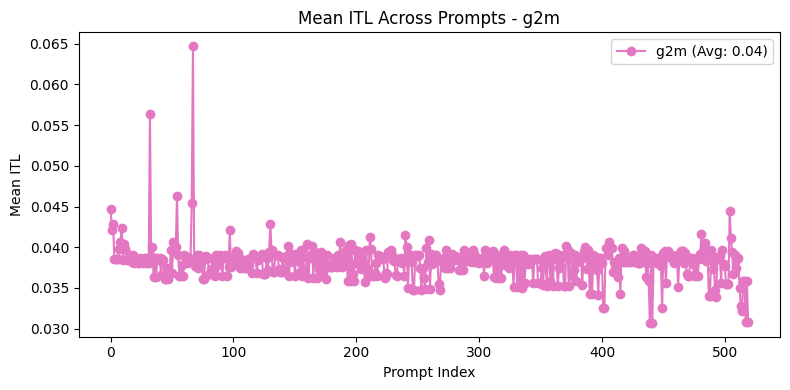

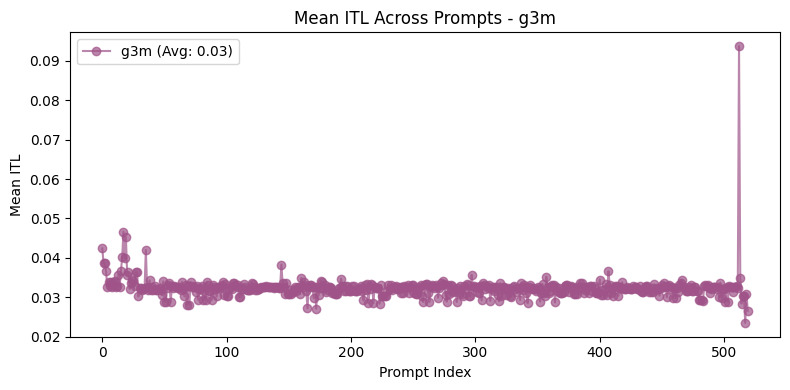

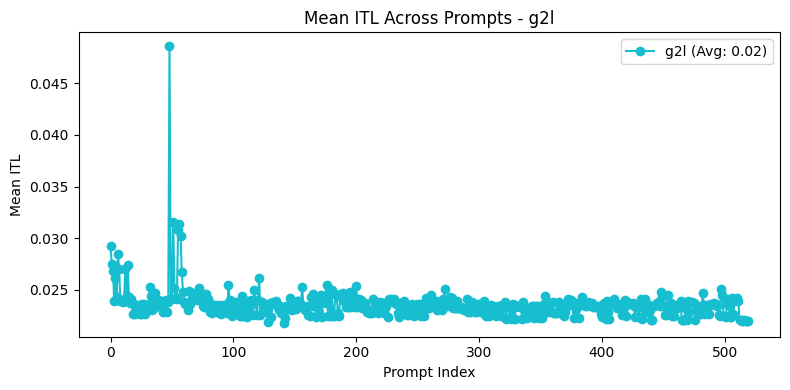

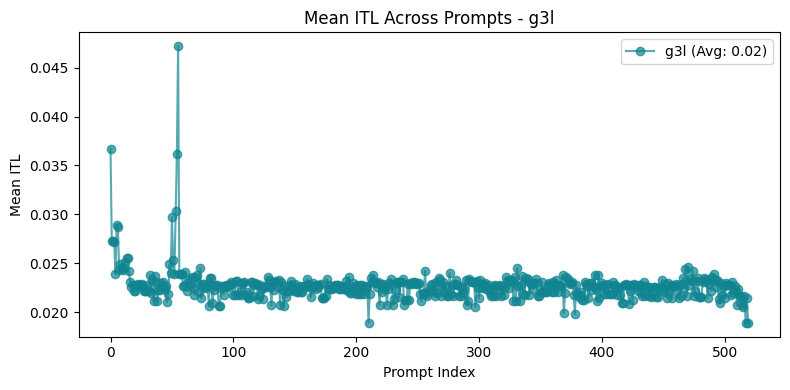

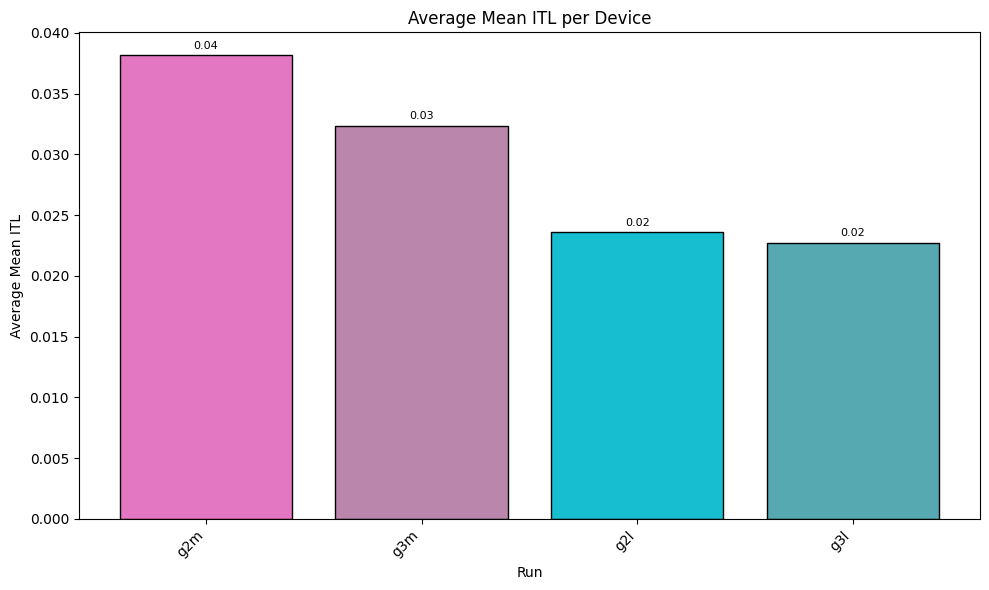

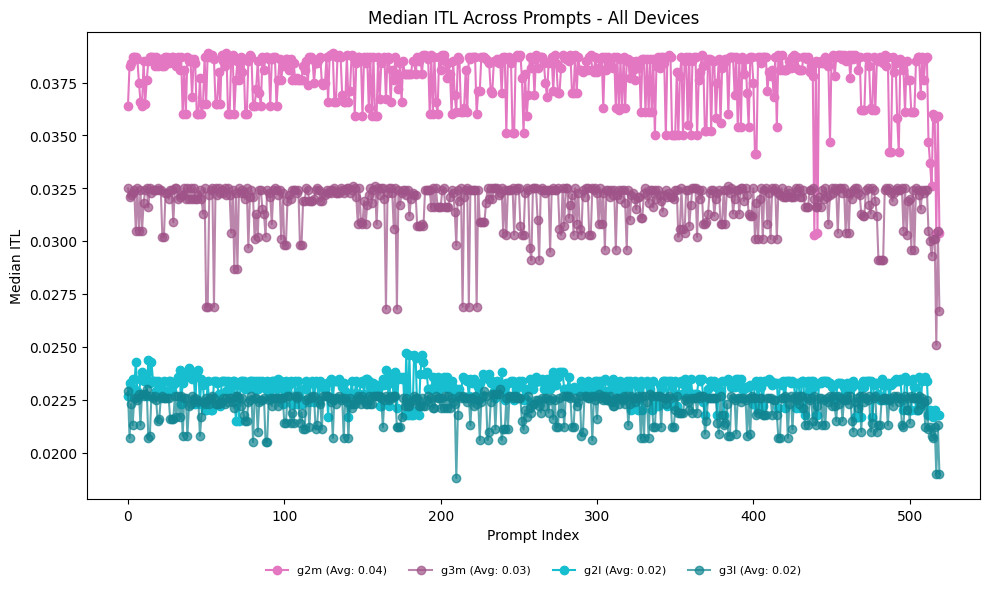

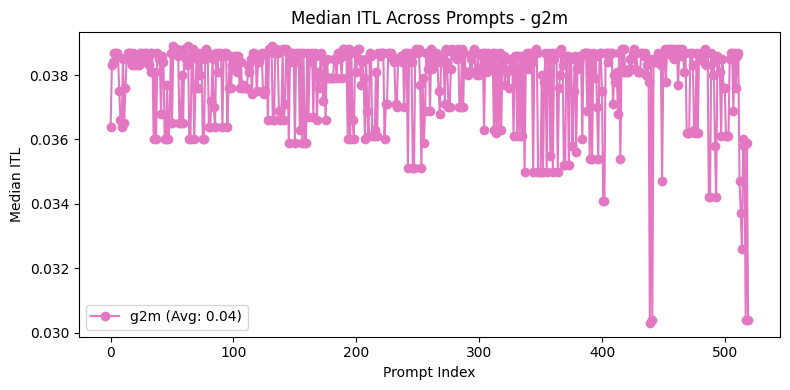

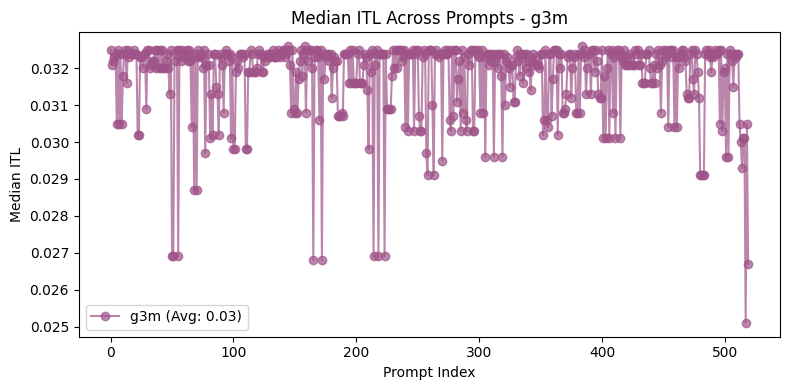

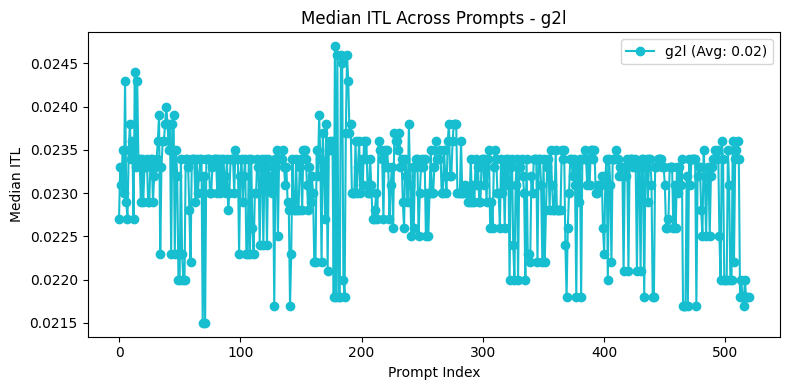

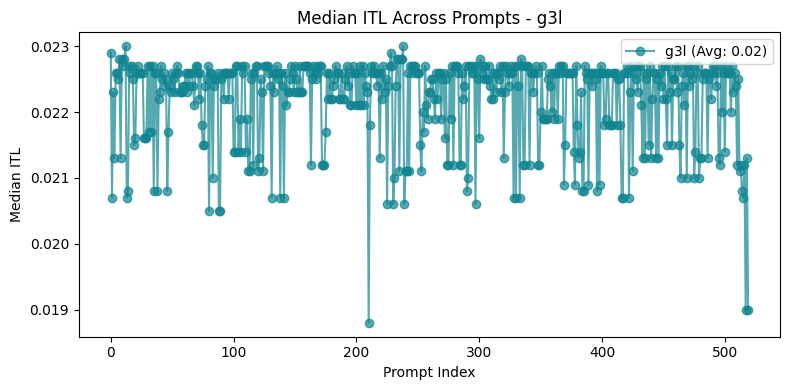

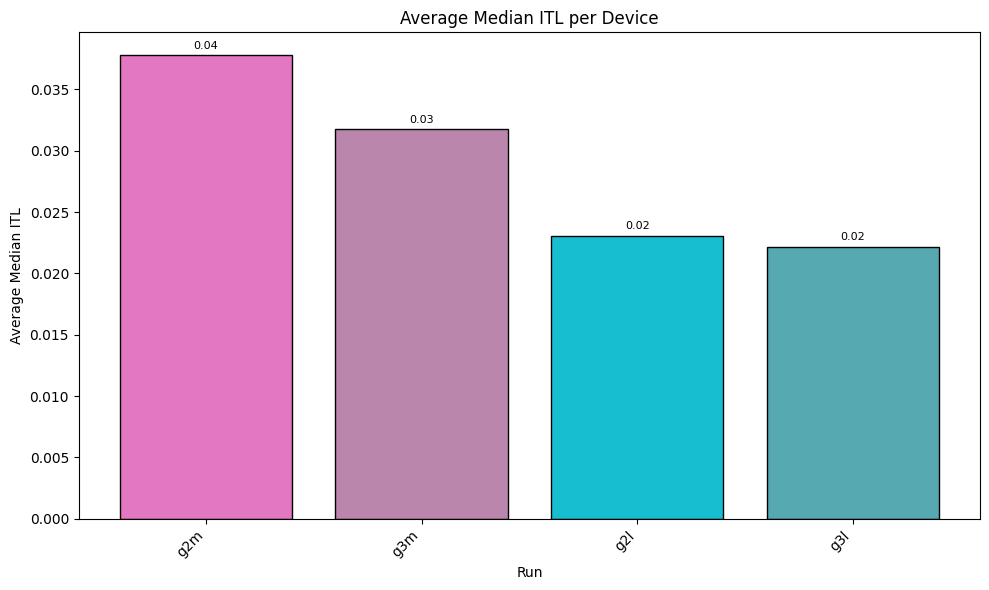

In [ ]:
import matplotlib.cm as cm
import numpy as np
import matplotlib.pyplot as plt

# The following variables are expected to be defined in previous cells:
# bench_plot_order, bench_sorted_runs, base_configs, base_color_list, bench_color_map

def get_cfg_key(run_name):
    # Extract config like "2", "3", "2s", "3m" from filename
    return run_name.split("_")[-1].replace("g", "")  # remove "g" if present

# Ensure bench_sorted_runs and bench_color_map are defined
# (These should be defined by the throughput plotting cell, re-executing it if needed)
bench_plot_order = ["2", "3", "2s", "3s", "2m", "3m", "2l", "3l"]

bench_sorted_runs = sorted(
    bench_data.keys(), # bench_data needs to be populated
    key=lambda x: bench_plot_order.index(get_cfg_key(x)) if get_cfg_key(x) in bench_plot_order else 999
)

base_configs = ["2", "2s", "2m", "2l"]
base_color_list = cm.tab10(np.linspace(0, 1, len(base_configs)))
bench_color_map = {}
for run in bench_sorted_runs:
    cfg = get_cfg_key(run)
    base_cfg = cfg.replace("3", "2")
    if base_cfg not in base_configs:
        base_cfg = base_configs[0]
    base_idx = base_configs.index(base_cfg)
    if cfg.startswith("2"):
        bench_color_map[run] = base_color_list[base_idx]
    else:
        bench_color_map[run] = tuple(np.array(base_color_list[base_idx]) * 0.7)

def plot_benchmark_metric(metric_name, metric_data_dict, metric_avg_dict):
    # Plot: All Devices for the current metric
    plt.figure(figsize=(10, 6))
    for run in bench_sorted_runs:
        plt.plot(
            metric_data_dict[run],
            marker='o',
            label=f"{run} (Avg: {metric_avg_dict[run]:.2f})",
            color=bench_color_map[run],
            linestyle="-"
        )
    plt.title(f"{metric_name} Across Prompts - All Devices")
    plt.xlabel("Prompt Index")
    plt.ylabel(metric_name)
    plt.legend(
        fontsize=8,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.12),
        ncol=4,
        frameon=False
    )
    plt.tight_layout()
    plt.show()

    # Individual Plots for the current metric
    for run in bench_sorted_runs:
        plt.figure(figsize=(8, 4))
        plt.plot(
            metric_data_dict[run],
            marker='o',
            color=bench_color_map[run],
            linestyle="-",
            label=f"{run} (Avg: {metric_avg_dict[run]:.2f})"
        )
        plt.title(f"{metric_name} Across Prompts - {run}")
        plt.xlabel("Prompt Index")
        plt.ylabel(metric_name)
        plt.legend()
        plt.tight_layout()
        plt.show()

    # Histogram for the current metric
    plt.figure(figsize=(10, 6))
    avg_values = [metric_avg_dict[run] for run in bench_sorted_runs]
    plt.bar(bench_sorted_runs, avg_values, color=[bench_color_map[run] for run in bench_sorted_runs], edgecolor="black")
    for i, val in enumerate(avg_values):
        plt.text(i, val + 0.01 * max(avg_values), f"{val:.2f}", ha="center", va="bottom", fontsize=8)
    plt.title(f"Average {metric_name} per Device")
    plt.xlabel("Run")
    plt.ylabel(f"Average {metric_name}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Call the function for TTFT
plot_benchmark_metric("TTFT", bench_ttft_data, bench_ttft)

# Call the function for Mean ITL
plot_benchmark_metric("Mean ITL", bench_mean_itl_data, bench_mean_itl)

# Call the function for Median ITL
plot_benchmark_metric("Median ITL", bench_median_itl_data, bench_median_itl)
